#Aim of the Notebook

The aim of this notebook is to compare how different optimization algorithms—specifically Gradient Descent, Momentum, and Nesterov Momentum—behave when searching for the minimum of a simple function that has two local minima and one global minimum.
This notebook also allows you to experiment with parameters so you can build intuition about how each parameter influences the optimization process.

## The Function

The loss function used in this notebook is:

f(x) = (x^2 - 1)**2 * (x^2 - 3)


This function has **two local minima** and **one global minimum**.  
The **global minimum** occurs at **\(x = 0\)**, where **\(f(0) = -3\)**.

We are trying to find the global minimul of that loss function using different algorithms.


In [26]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from ipywidgets import interact, FloatSlider

<Axes: xlabel='x', ylabel='y'>

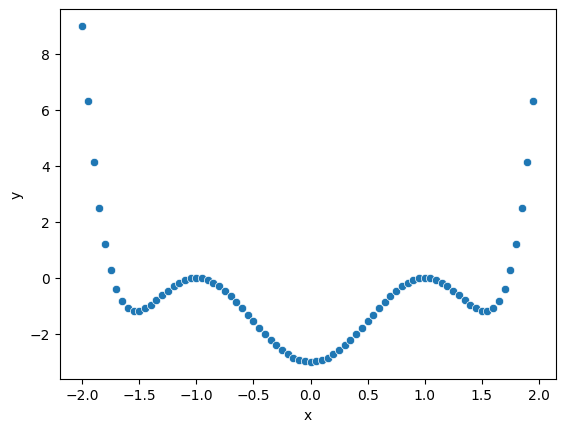

In [27]:
x = np.arange(-2, 2, 0.05)
y = (x*x-1)* (x*x-3)* (x*x-1)
df = pd.DataFrame({'x': x, 'y': y})
sns.scatterplot(df, x = 'x', y = 'y')

## Gradient Descent

The first thing we will try is to find the global minimum using the classical **Gradient Descent** algorithm. In our case, the parameter we update is simply **\(x\)**, and the loss function is the previously defined **\(f(x)\)**.

Thus, the standard Gradient Descent update rule becomes:


Delta x = -n*f'(x) where n is the learning rate.




In [28]:
def gradient_descent(start, iterations, learning_rate):
  #main gradient descent code
  Xs = [start]
  w = start

  for _ in range(iterations):
    w -= learning_rate * gradient(w)
    Xs.append(w)
  #end of the main gradient descent code
  Xs = np.array(Xs)
  Ys =(Xs*Xs-1)* (Xs*Xs-1)* (Xs*Xs-3)
  x = np.arange(-2, 2, 0.05)
  y =  x*x - 4*x + 8
  y = (x*x-1)* (x*x-3)* (x*x-1)
  df = pd.DataFrame({'x': x, 'y': y})
  df_path = pd.DataFrame({'y': Ys, 'x': Xs})
  return df, df_path
#calculation of the gradient of our function
def gradient(w):
  return 2*(w*w-1)*2*w*(w*w-3) + (w*w-1)*(w*w-1)*2*w

In [29]:
# @title
#this is the code for plotting and animating my simulations
def animating(df, df_path):
  fig, ax = plt.subplots()

# scat: static points
  scat = ax.scatter(df['x'], df['y'], c="b", s=5)

# scat_2: will be animated, start from first point
  scat_2 = ax.scatter(df_path['x'][0], df_path['y'][0], c="r", s=20)

  ax.set(xlabel='x', ylabel='y')


  def update(frame):
    # only update scat_2
      x2 = df_path['x'][:frame]
      y2 = df_path['y'][:frame]
      data2 = np.stack([x2, y2]).T
      scat_2.set_offsets(data2)
      return scat_2

  ani = animation.FuncAnimation(
      fig=fig,
      func=update,
      frames=len(df_path),
      interval=150
  )
  plt.close(fig)
  return HTML(ani.to_jshtml())
def plot_gradient_descent(iterations=20, learning_rate=0.01):
  df, df_path= gradient_descent(-2, int(iterations), learning_rate)
  return animating(df, df_path)


In [42]:
# @title

%matplotlib inline

# This must be the last line in the cell
interact(
    plot_gradient_descent,
    iterations=FloatSlider(value=20, min=0, max=50, step=1, description="Iterations"),
    learning_rate=FloatSlider(value=0.01, min=0.005, max=0.06, step=0.005, description="Learning rate", readout_format='.3f'),
);



interactive(children=(FloatSlider(value=20.0, description='Iterations', max=50.0, step=1.0), FloatSlider(value…

### Effect of the Learning Rate when using Gradient Descent

With a learning rate of **0.01**, the optimizer is not able to escape the first local minimum and ends up getting stuck there.

When we increase the learning rate to **0.2**, the optimizer gains enough momentum to bypass the local minimum and converges to the **global minimum**.

However, if we increase the learning rate too much (e.g., to **0.6**), the updates overshoot both the first local minimum and the global minimum, eventually landing in the **second local minimum** instead.

This demonstrates how crucial it is to experiment with different learning rates when using Gradient Descent.


# Gradient Descent with Momentum

Gradient Descent with Momentum is an extension of classical Gradient Descent, inspired by physics.  
The key idea is to introduce a **velocity term** that accumulates information from past gradients.  
This velocity pushes the updates forward, allowing the optimizer to keep moving even when the current gradient becomes small or briefly points in the opposite direction.

With enough accumulated momentum, the algorithm can:

- overcome shallow local minima,
- reduce oscillations in regions with steep or curved slopes,
- and reach the minimum faster than standard Gradient Descent.

In essence, momentum smooths and accelerates the optimization path.


In [49]:
def gradient_descent_with_momentum(start, iterations, learning_rate, momentum):
  Xs = [start]
  w = start
  v = 0
  for _ in range(iterations):
    v = momentum * v + learning_rate * gradient(w)
    w -= v
    Xs.append(w)

  Xs = np.array(Xs)
  Ys =(Xs*Xs-1)* (Xs*Xs-1)* (Xs*Xs-3)
  x = np.arange(-2, 2, 0.05)
  y = (x*x-1)* (x*x-3)* (x*x-1)
  df = pd.DataFrame({'x': x, 'y': y})
  df_path = pd.DataFrame({'y': Ys, 'x': Xs})
  return df, df_path
  return np.array(Xs)


In [48]:
# @title


def plot_gradient_descent_with_momentum(iterations=20, learning_rate=0.01, momentum = 0.6):
  df, df_path= gradient_descent_with_momentum(-2, int(iterations), learning_rate, momentum)
  return animating(df, df_path)

# This must be the last line in the cell
interact(
    plot_gradient_descent_with_momentum,
    iterations=FloatSlider(value=20, min=0, max=50, step=1, description="Iterations"),
    learning_rate=FloatSlider(value=0.01, min=0.01, max=0.03, step=0.005, description="Learning rate", readout_format='.3f'),
    momentum=FloatSlider(value=0.6, min=0.1, max=1, step=0.1, description="Momentum"),
);

interactive(children=(FloatSlider(value=20.0, description='Iterations', max=50.0, step=1.0), FloatSlider(value…

### Observing the Effect of Momentum

From this example, we can see that when the learning rate is **0.01** and the momentum term is greater than **0.5**, the optimizer is able to overcome the first local minimum.  
With simple Gradient Descent, this was not possible at the same learning rate.

However, when the momentum is too high (e.g., **0.9**), the optimizer overshoots the global minimum.  
Interestingly, after overshooting, the accumulated velocity gradually decreases, allowing the optimizer to slowly return toward the global minimum.

The next question is on how to prevent overshooting the global minima?



## Nesterov Momentum

Nesterov Momentum improves upon classical momentum by taking a **lookahead step** before computing the gradient.  
Instead of evaluating the gradient at the current position \(x_t\), it evaluates it at the position **where the momentum is about to take us**.

This means the update uses information not only from past gradients but also from the **anticipated future position**, making the optimization path more stable and controlled.

As a result, Nesterov Momentum often:

- reduces overshooting of the global minimum,
- provides smoother convergence,
- and handles complex loss landscapes more effectively.

Nesterov Momentum is particularly useful when training deep networks with complicated curvature and many saddle points, where classical momentum may oscillate or overshoot.



In [33]:
def Nesterov(start, iterations, learning_rate, momentum):
  Xs = [start]
  w = start
  v = 0
  for _ in range(iterations):
    wprev = w
    w += momentum * v
    v = momentum*v-learning_rate * gradient(w)
    w = wprev + v
    Xs.append(w)
  Xs = np.array(Xs)

  Ys =(Xs*Xs-1)* (Xs*Xs-1)* (Xs*Xs-3)
  x = np.arange(-2, 2, 0.05)
  y = (x*x-1)* (x*x-3)* (x*x-1)
  df = pd.DataFrame({'x': x, 'y': y})
  df_path = pd.DataFrame({'y': Ys, 'x': Xs})
  return df, df_path
  return np.array(Xs)


In [43]:
# @title

def plot_Nesterov(iterations=20, learning_rate=0.01, momentum = 0.9):
  df, df_path= Nesterov(-2, int(iterations), learning_rate, momentum)
  return animating(df, df_path)

# This must be the last line in the cell
interact(
    plot_Nesterov,
    iterations=FloatSlider(value=20, min=0, max=50, step=10, description="Iterations"),
    learning_rate=FloatSlider(value=0.005, min=0.005, max=0.03, step=0.005, description="Learning rate", readout_format = '.3f'),
    momentum=FloatSlider(value=0.9, min=0.3, max=1, step=0.1, description="Momentum"),)

interactive(children=(FloatSlider(value=20.0, description='Iterations', max=50.0, step=10.0), FloatSlider(valu…

<function __main__.plot_Nesterov(iterations=20, learning_rate=0.01, momentum=0.9)>

## Effects of Nesterov Momentum

When we compare classical Momentum with Nesterov Momentum using the same learning rate and momentum term (for example, a learning rate of **0.01** and momentum **0.9**), we see that both methods overshoot the global minimum.  

However, Nesterov Momentum provides a **much smoother convergence** once it enters the region near a minimum.  
This is because the gradient is computed at the *lookahead* position, allowing the update to anticipate future behavior and correct its trajectory earlier.

If you want to see how unstable high momentum can become, try increasing the learning rate slightly (e.g., to **0.015**) while keeping momentum at **0.9**.  
You will notice that the updates can become very large, demonstrating how strongly Nesterov amplifies the effects of both the learning rate and the momentum term.


In [35]:
# @title
def Adam(start, iterations, learning_rate, b1=0.9, b2=0.99):
    Xs = [start]
    w = start
    e = 1e-8
    m = 0
    v = 0
    for t in range(1, iterations + 1):
        grad = gradient(w)
        m = b1 * m + (1 - b1) * grad
        v = b2 * v + (1 - b2) * (grad ** 2)
        m_hat = m / (1 - b1 ** t)
        v_hat = v / (1 - b2 ** t)
        w -= learning_rate * m_hat / (np.sqrt(v_hat) + e)
        Xs.append(w)
    Xs = np.array(Xs)
    Ys =(Xs*Xs-1)* (Xs*Xs-1)* (Xs*Xs-3)
    x = np.arange(-2, 2, 0.05)
    y = (x*x-1)* (x*x-3)* (x*x-1)
    df = pd.DataFrame({'x': x, 'y': y})
    df_path = pd.DataFrame({'y': Ys, 'x': Xs})
    return df, df_path



In [ ]:
# @title

def plot_Adam(iterations=20, learning_rate=0.01, b1=0.9, b2 = 0.99):
  df, df_path= Adam(-2, int(iterations), learning_rate, b1, b2)
  return animating(df, df_path)

# This must be the last line in the cell
interact(
    plot_Adam,
    iterations=FloatSlider(value=20, min=0, max=50, step=1, description="Iterations"),
    learning_rate=FloatSlider(value=0.01, min=0.005, max=0.06, step=0.005, description="Learning rate"),
    b1=FloatSlider(value=0.9, min=0.5, max=1, step=0.01, description="b1"),
    b2=FloatSlider(value=0.99, min=0.5, max=1, step=0.01, description="b2"))